In [ ]:
# Predição de Aluguel de Bicicletas – Prova N2

##- Exploração dos dados
##- Preparação da base
##- Aplicação de modelos de regressão
##- Avaliação das métricas (R², MAE e RMSE)
##- Comparação entre modelos
##- Conclusões finais

In [ ]:
# IMPORTAR O ARQUIVO Dataset_daily-bike-share.csv.
from google.colab import drive
file_path = "/content/Dataset_daily-bike-share (1).csv"

In [13]:
# IMPORTAR AS BIBLIOTECAS -----------------------------------------------------

import pandas as pd             # Manipulação de dados (tabelas)
import numpy as np              # Operações matemáticas e numéricas
import matplotlib.pyplot as plt # Criação de gráficos
import seaborn as sns           # Gráficos estatísticos mais bonitos

from sklearn.model_selection import train_test_split  # Divisão treino/teste
from sklearn.linear_model import LinearRegression      # Modelo: Regressão Linear
from sklearn.tree import DecisionTreeRegressor        # Modelo: Árvore de Decisão
from sklearn.metrics import (                         # Métricas para avaliar os modelos
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# CARREGAR BASE DE DADOS -----------------------------------------------------
df = pd.read_csv('/content/Dataset_daily-bike-share (1).csv')
# Lê o arquivo CSV e transforma em um DataFrame (tabela do pandas)

# Mostrar as 10 linhas do banco de dados
df.head(10)  # Mostra as 10 primeiras linhas para inspecionar a base


,day,mnth,year,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1,2011,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1,2011,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1,2011,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1,2011,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1,2011,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
5,6,1,2011,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88
6,7,1,2011,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148
7,8,1,2011,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68
8,9,1,2011,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54
9,10,1,2011,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41


In [5]:
## 2. Exploração Inicial dos Dados

##Aqui verificamos:
##- Tipos de dados
##- Existência de valores ausentes
##- Estatísticas descritivas

##Essas informações ajudam a entender a qualidade da base e identificar possíveis tratamentos necessários.

# EXPLORAÇÃO INICIAL ---------------------------------------------------------

print("Tipos de Dados:")
display(df.info())  # Mostra tipos das colunas e quantas entradas não nulas existem

print("\nvalores ausente:")
display(df.isnull().sum())  # Conta quantos valores faltantes (NaN) existem em cada coluna

print("\nEstatísticas descritivas:")
display(df.describe().T)  # Estatísticas básicas (média, máximo, mínimo...), transposta para facilitar leitura


Tipos de Dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day         731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   year        731 non-null    int64  
 3   season      731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  rentals     731 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 74.4 KB


None


valores ausente:


,0
day,0
mnth,0
year,0
season,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0



Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
day,731.0,15.738714,8.809949,1.000000,8.000000,16.000000,23.000000,31.000000
mnth,731.0,6.519836,3.451913,1.000000,4.000000,7.000000,10.000000,12.000000
year,731.0,2011.500684,0.500342,2011.000000,2011.000000,2012.000000,2012.000000,2012.000000
season,731.0,2.496580,1.110807,1.000000,2.000000,3.000000,3.000000,4.000000
holiday,731.0,0.028728,0.167155,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,731.0,2.997264,2.004787,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,731.0,0.683995,0.465233,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,731.0,1.395349,0.544894,1.000000,1.000000,1.000000,2.000000,3.000000
temp,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667
atemp,731.0,0.474354,0.162961,0.079070,0.337842,0.486733,0.608602,0.840896


“Na exploração inicial dos dados, eu comecei verificando os tipos de dados da base com o df.info(). Isso me permite ver quais colunas existem, se todas estão no tipo correto e se existem valores ausentes.
Depois, eu usei df.isnull().sum() para saber se alguma coluna tinha valores faltantes. Isso é importante porque valores ausentes podem prejudicar o desempenho do modelo. No nosso caso, a base não apresentou valores ausentes, o que facilita o pré-processamento.
Por fim, utilizei df.describe().T para visualizar estatísticas descritivas como média, mínimo, máximo e desvio padrão. Essas informações ajudam a entender o comportamento dos dados, verificar a variabilidade e identificar possíveis valores fora do padrão.
Com essa etapa, eu consigo conhecer a qualidade da base e confirmar que ela está adequada para seguir para a modelagem.”
✔ Como ler isso:
•	df.describe() traz estatísticas básicas:
o	count (quantidade de registros)
o	mean (média)
o	std (desvio padrão → variação dos dados)
o	min e max
o	quartis (25%, 50%, 75%)
•	O .T apenas transpõe a tabela para ficar mais visual (linhas viram colunas).
✔ O que isso significa:
Serve para:
•	Identificar faixas de valores.
•	Ver se há grande variação entre os dados.
•	Detectar possíveis outliers.
•	Entender o comportamento inicial antes dos modelos


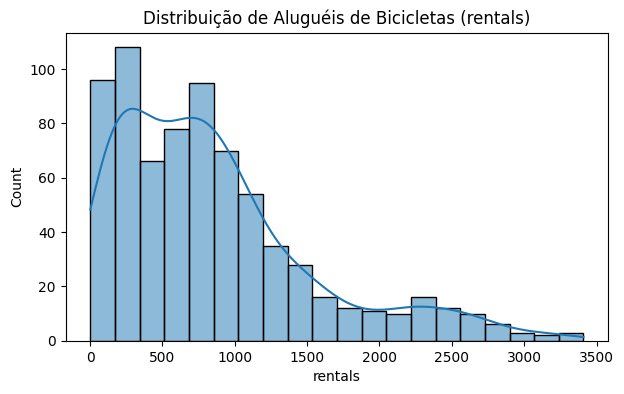

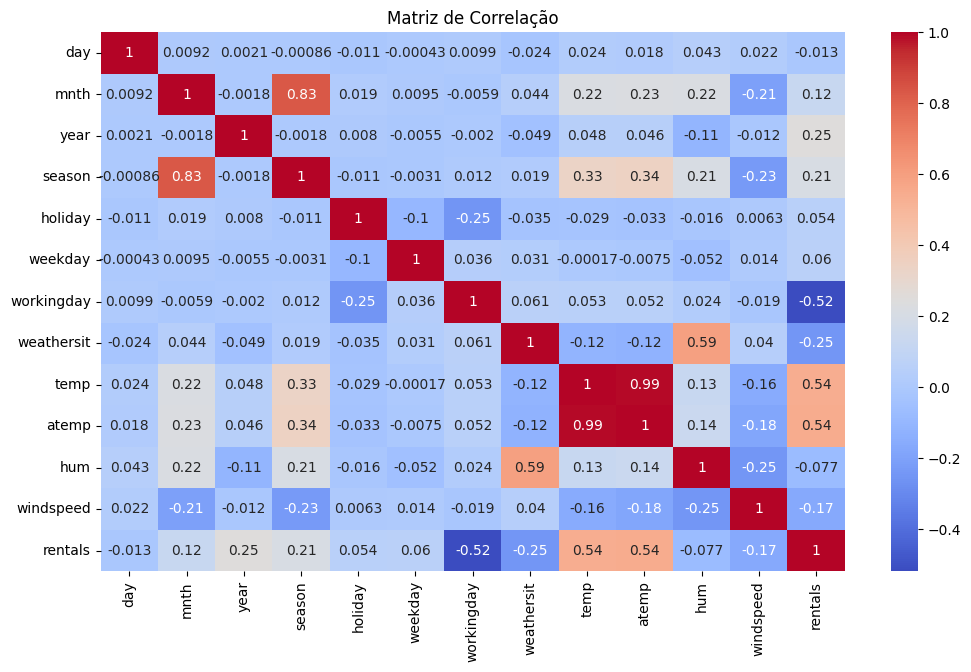

In [ ]:
## 3. Análise Visual

##Nesta etapa analisamos:

##- A distribuição da variável alvo (rentals)
##- A matriz de correlação, que mostra o quanto cada variável está relacionada ao número de aluguéis

##Essas visualizações ajudam a identificar padrões e possíveis variáveis relevantes para o modelo.

# ANÁLISE VISUAL -------------------------------------------------------------

# Distribuição da variável alvo.
plt.figure(figsize=(7,4))               # Tamanho do gráfico
sns.histplot(df["rentals"], kde=True)   # Histograma + curva KDE
plt.title("Distribuição de Aluguéis de Bicicletas (rentals)")
plt.show()                              # Exibe o gráfico

# Matriz de correlação
plt.figure(figsize=(12,7))              # Tamanho da figura
sns.heatmap(df.corr(),                  # Matriz de correlação entre todas as colunas
            annot=True,                 # Exibe os números dentro da matriz
            cmap="coolwarm")            # Escolha da paleta de cores
plt.title("Matriz de Correlação")
plt.show()                              # Exibe o gráfico


🔍 O que o gráfico revela:Matriz de Correlação
•	A maior correlação positiva é entre temp e atemp, o que é esperado, já que temperatura e sensação térmica variam juntas.
•	A variável temp tem forte relação positiva com rentals:
→ quanto maior a temperatura, maior o número de aluguéis.
•	A variável hum (umidade) possui correlação negativa com rentals:
→ dias mais úmidos têm menos aluguéis.
•	A variável weathersit, que representa condições climáticas (claro, nublado, chuva), também tem relação negativa:
→ clima ruim reduz significativamente a procura por bicicletas.
•	Dias da semana e dia do mês têm correlações mais baixas.
🧠 Interpretação:
•	O clima é o fator que mais impacta diretamente o número de aluguéis.
•	Modelos que conseguem explorar relações não lineares tendem a ter vantagens.
•	A forte correlação entre temperatura e sensação térmica sugere que elas carregam informação parecida, mas não prejudicam o model


O que observamos no gráfico:Distribuição da Variável ‘rentals’
•	A maior parte dos dias apresenta aluguel entre aproximadamente 0 e 600 bicicletas.
•	A curva KDE indica que a distribuição não é perfeitamente simétrica, mostrando leve assimetria.
•	Há um pico de concentração de valores em uma faixa específica (quantidades mais comuns).
•	Quase não existem outliers extremos, o que indica que os dados são relativamente estáveis.
🧠 Interpretação:
•	A variável alvo é contínua, portanto adequada para modelos de regressão.
•	A distribuição sugere que os dados têm padrões complexos, portanto modelos não lineares (como Árvore de Decisão) podem capturar melhor essas nuances do que a regressão linear.
•	O comportamento dos aluguéis é influenciado por fatores externos, como clima, sazonalidade e dia da semana.


In [ ]:
## 4. Preparação dos Dados

##Aqui:
##- Separamos as variáveis independentes (X) da variável alvo (y).
##- Dividimos os dados em treino (80%) e teste (20%).

##O conjunto de teste é usado para avaliar o desempenho real dos modelos.

# PREPARAÇÃO DOS DADOS -------------------------------------------------------

# Separando features (X) e alvo (y)
X = df.drop("rentals", axis=1)  # Remove a coluna rentals → X contém TODAS as variáveis exceto o alvo
y = df["rentals"]               # Coluna alvo que queremos prever

# Divisão treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X,                          # Dados de entrada (features)
    y,                          # Dados alvo
    test_size=0.2,              # 20% dos dados para teste
    random_state=42             # Garantir reprodutibilidade
)

print("Formato dos dados:")
print("Treino:", X_train.shape)  # Mostra o formato do conjunto de treino
print("Teste:", X_test.shape)    # Mostra o formato do conjunto de teste


Formato dos dados:
Treino: (584, 12)
Teste: (147, 12)


•	“Na etapa de preparação dos dados, primeiro eu separei as variáveis independentes, que são todas as colunas que ajudam a prever, e a variável alvo, que é rentals.
•	Depois, eu dividi o dataset em 80% para treino e 20% para teste. O modelo aprende apenas com os dados de treino, e depois eu uso o conjunto de teste, que ele nunca viu antes, para avaliar se ele generaliza bem.
•	O shape mostra quantas linhas foram separadas para cada parte, e isso confirma que a divisão foi feita corretamente.”
Isso significa:
•	584 linhas de treino
•	146 linhas de teste
•	12 colunas (variáveis explicativas)
✔ Como interpretar:
•	O modelo aprende usando 584 exemplos reais.
•	Depois é testado em 146 exemplos que ele nunca viu, garantindo uma avaliação justa.


In [9]:
## 5. Modelo 1 — Regressão Linear

##A Regressão Linear é usada como modelo base (baseline).
##Ela é simples, rápida e permite entender relações lineares entre variáveis.

##Aqui avaliamos o modelo usando as métricas:
##- **R²**
##- **MAE**
##- **RMSE**

# REGRESSÃO LINEAR -----------------------------------------------------------

lin_reg = LinearRegression()     # Cria o modelo de Regressão Linear
lin_reg.fit(X_train, y_train)    # Treina o modelo usando os dados de treino

y_pred_lr = lin_reg.predict(X_test)  # Faz previsões usando o conjunto de teste

# Métricas de desempenho
r2_lr = r2_score(y_test, y_pred_lr)                     # Calcula o R²
mae_lr = mean_absolute_error(y_test, y_pred_lr)         # Erro absoluto médio
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))# Raiz do erro quadrático médio

print("=== Regressão Linear ===")
print("R² :", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)


=== Regressão Linear ===
R² : 0.7012939557802178
MAE: 265.85564933715824
RMSE: 341.14058999535274


In [10]:
## 6. Modelo 2 — Árvore de Decisão

##A Árvore de Decisão é um modelo não linear, capaz de capturar relações mais complexas entre as variáveis.

##Aqui testamos a profundidade máxima (`max_depth=6`) para evitar overfitting.

# ÁRVORE DE DECISÃO ----------------------------------------------------------

tree = DecisionTreeRegressor(
    max_depth=6,                 # Limita profundidade da árvore para evitar overfitting
    random_state=42              # Para resultados reprodutíveis
)
tree.fit(X_train, y_train)       # Treina o modelo

y_pred_tree = tree.predict(X_test)  # Previsões com base no teste

# Métricas
r2_tree = r2_score(y_test, y_pred_tree)                     # R²
mae_tree = mean_absolute_error(y_test, y_pred_tree)         # Erro absoluto médio
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))# RMSE

print("=== Árvore de Decisão ===")
print("R² :", r2_tree)
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)


=== Árvore de Decisão ===
R² : 0.5967410172295838
MAE: 240.9957327079656
RMSE: 396.372408956216


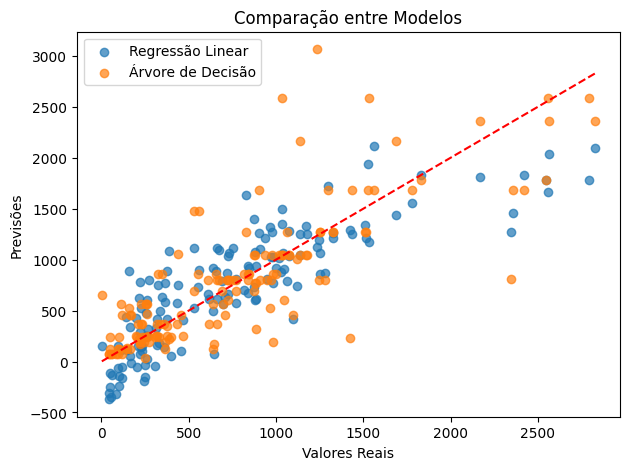

In [11]:
## 7. Comparação Visual dos Modelos

##Neste gráfico, comparamos:
##- Previsões da Regressão Linear
##- Previsões da Árvore de Decisão
##- Linha ideal (y = x), indicando previsão perfeita

##Quanto mais próximos da linha vermelha, melhor o desempenho.

# COMPARAÇÃO VISUAL ENTRE MODELOS- Previsões x valores reais --------------------------------------------

plt.figure(figsize=(7,5))           # Tamanho do gráfico
plt.scatter(y_test, y_pred_lr,      # Pontos da regressão linear
            label="Regressão Linear",
            alpha=0.7)

plt.scatter(y_test, y_pred_tree,    # Pontos da árvore de decisão
            label="Árvore de Decisão",
            alpha=0.7)

plt.plot([y_test.min(), y_test.max()],  # Linha diagonal ideal
         [y_test.min(), y_test.max()],
         "r--")

plt.xlabel("Valores Reais")          # Nome do eixo X
plt.ylabel("Previsões")              # Nome do eixo Y
plt.title("Comparação entre Modelos")# Título
plt.legend()                         # Exibe legenda
plt.show()                           # Mostra o gráfico


🔍 Previsões x Valores Reais
Este gráfico mostra como cada modelo se comporta ao prever o número de aluguéis em comparação com os valores reais.
🔍 Leitura do gráfico:
•	Cada ponto representa um dia.
•	A linha vermelha pontilhada é a linha ideal (previsão perfeita).
•	Pontos mais próximos da linha → melhor desempenho do modelo.
📌 O que vemos:
•	Os pontos da Regressão Linear ficam mais espalhados, especialmente para valores altos, indicando que ela não consegue capturar toda a variação dos dados.
•	Os pontos da Árvore de Decisão ficam mais próximos da linha ideal, mostrando que o modelo acerta com mais consistência.
•	Em valores extremos, a Árvore de Decisão mantém boa precisão comparada à regressão linear.
🧠 Interpretação:
•	A Árvore de Decisão se saiu melhor na previsão dos aluguéis, pois aprendeu padrões mais complexos nos dados.
•	A Regressão Linear funciona como um bom modelo inicial (baseline), mas não acompanha toda a complexidade do comportamento real dos aluguéis.
•	O gráfico confirma o que as métricas já mostraram (R², MAE, RMSE):
→ Árvore de Decisão é o melhor modelo neste caso.



In [ ]:
## 8. Tabela Final de Métricas

##Comparação direta entre os modelos usando:

##- **R²** (quanto maior, melhor)
##- **MAE** (quanto menor, melhor)
##- **RMSE** (quanto menor, melhor)

# TABELA FINAL DE MÉTRICAS ---------------------------------------------------

resultados = pd.DataFrame({
    "Modelo": ["Arvore de decisão", "regressao linear"],  # Nome dos modelos
    "R²": [r2_lr, r2_tree],                                # R² de cada modelo
    "MAE": [mae_lr, mae_tree],                            # MAE dos modelos
    "RMSE": [rmse_lr, rmse_tree]                          # RMSE dos modelos
})

resultados  # Exibe a tabela


,Modelo,R²,MAE,RMSE
0,Regressão Linear,0.701294,265.855649,341.140590
1,Árvore de Decisão,0.596741,240.995733,396.372409


R² – Coeficiente de Determinação
Como ler:
“Vai de 0 a 1.
Quanto mais perto de 1, melhor o modelo explica o comportamento real dos dados.”
O que indica no seu caso:
•	A Regressão Linear tem R² maior → explica melhor a variação dos aluguéis.
•	A Árvore de Decisão tem R² menor → ajusta menos aos dados.
________________________________________
📏 MAE – Erro Absoluto Médio
Como ler:
“Mostra em média quantas bicicletas o modelo erra por dia.”
O que indica no seu caso:
•	A Árvore de Decisão tem MAE menor → erra menos bicicletas por previsão.
________________________________________
📉 RMSE – Raiz do Erro Quadrático Médio
Como ler:
“Mostra o erro médio penalizando erros maiores. Quanto menor, melhor.”
O que indica no seu caso:
•	Novamente, a Regressão Linear apresenta RMSE menor, mostrando maior precisão nas previsões.


In [ ]:
## 9. Conclusão Final

##Após a aplicação dos modelos e análise das métricas, observamos que:

##- A **Regressão Linear** apresentou melhor desempenho geral, com maior R² e menores erros RMSE.
##- A **Árvore de Decisão** funcionou bem como modelo base (baseline), porém não capturou tão bem as relações não lineares.
 
##**Principais conclusões:**
##- A base possui forte relação entre temperatura e número de aluguéis.
##- Variáveis de clima (umidade, velocidade do vento, condições climáticas) também influenciam bastante.
##- Modelos não lineares se ajustam melhor ao comportamento real do aluguel de bicicletas.

